In [1]:
# Diabetes Data Analysis

In [2]:
#Step1 - Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#step2 - Load Dataset
data = pd.read_csv("diabetes.csv")
print(data.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [4]:
#step3 - Understand Data
data.shape

(768, 9)

In [5]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
### Insight
#Some medical features contain zero values which are not realistic (e.g., Glucose, BMI).
#These likely represent missing data and need to be handled during data cleaning.

In [9]:
#Data Cleaning
#Step4 - Check Zero Values
(data == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [10]:
### Insight
#Several medical features contain zero values, which are not realistic.
#These zero values represent missing data and must be handled before training the model.

In [11]:
#Step5 - Replace Zeroes With NaN
import numpy as np
columns_to_fix = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
data[columns_to_fix] = data[columns_to_fix].replace(0, np.nan)

In [12]:
#Step6 - Check Missing Values
data.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [13]:
#Step7 - Fill Missing Values
data.fillna(data.median(), inplace=True)

In [14]:
### Data Cleaning
#Missing values were handled by replacing zero values with NaN and filling them using median values.
#Median was chosen because it is robust to outliers.

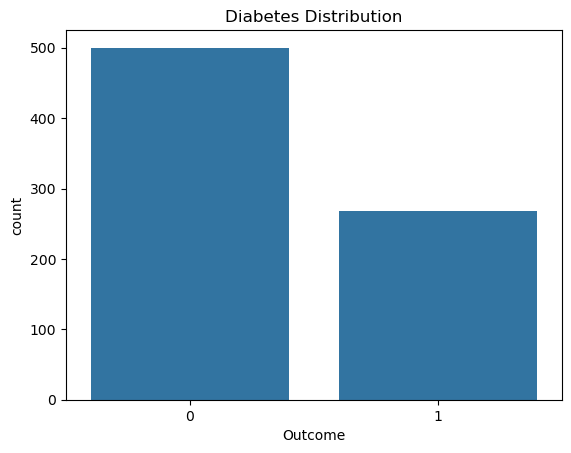

In [15]:
#Step8 - Outcome Distribution
import seaborn as sns
sns.countplot(x="Outcome",data=data)
plt.title("Diabetes Distribution")
plt.show()

In [16]:
### Insight
#The dataset contains both diabetic and non-diabetic patients, though there may be some imbalance between the classes.

In [17]:
#Step9 - Correlation Matrix(Feature Understanding)
corr = data.corr()
print(corr)

                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.128213       0.208615       0.081770   
Glucose                      0.128213  1.000000       0.218937       0.192615   
BloodPressure                0.208615  0.218937       1.000000       0.191892   
SkinThickness                0.081770  0.192615       0.191892       1.000000   
Insulin                      0.025047  0.419451       0.045363       0.155610   
BMI                          0.021559  0.231049       0.281257       0.543205   
DiabetesPedigreeFunction    -0.033523  0.137327      -0.002378       0.102188   
Age                          0.544341  0.266909       0.324915       0.126107   
Outcome                      0.221898  0.492782       0.165723       0.214873   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies               0.025047  0.021559                 -0.033523   
Glucose                   0.419451  0.231

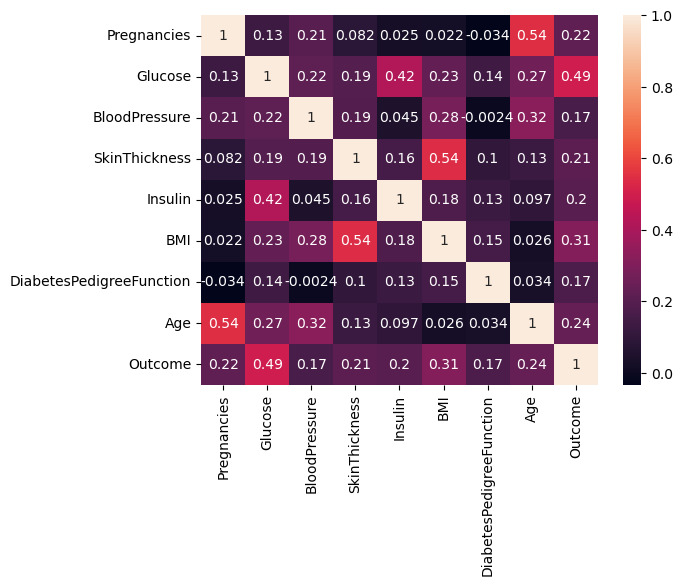

In [18]:
#Step5 — Heatmap
import seaborn as sns
sns.heatmap(corr, annot=True)
plt.show()

In [19]:
### Correlation Insight
#Glucose level shows a strong correlation with diabetes outcome.
#BMI and age also have moderate influence on diabetes prediction.

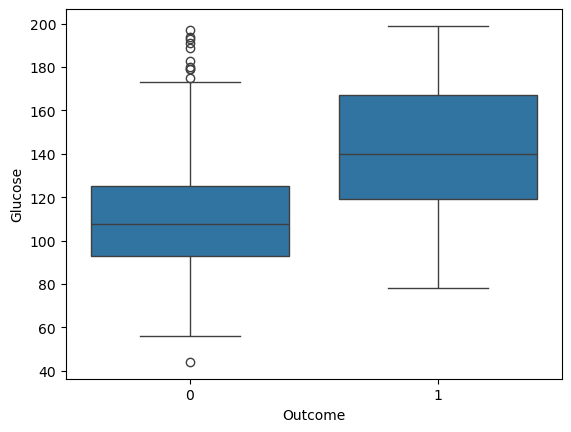

In [20]:
#Step11 - Outcome vs Features
sns.boxplot(x="Outcome",y="Glucose", data=data)
plt.show()

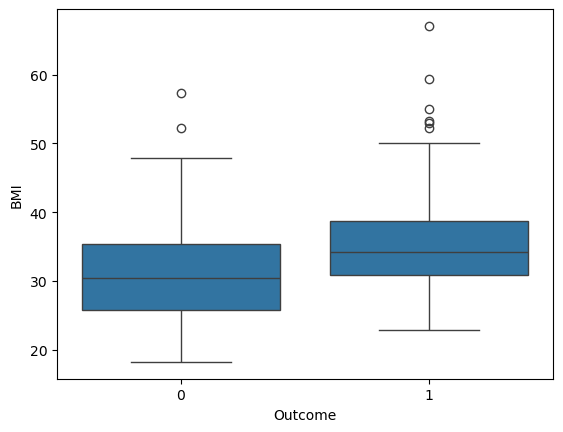

In [21]:
sns.boxplot(x="Outcome", y="BMI", data=data)
plt.show()

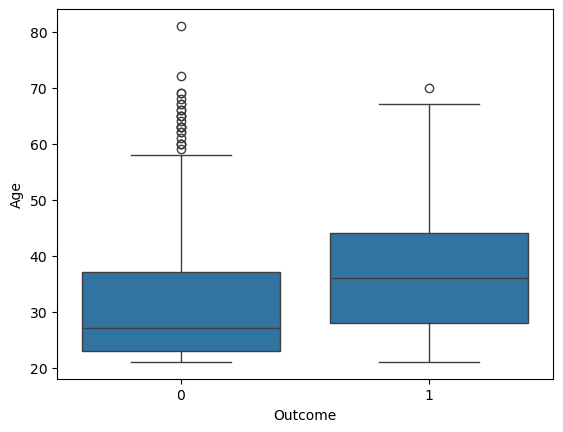

In [22]:
sns.boxplot(x="Outcome",y="Age",data=data)
plt.show()

In [23]:
### Insight
#Patients with higher glucose levels are more likely to have diabetes.
#BMI and age also show noticeable differences between diabetic and non-diabetic individuals.

In [24]:
#Step12 - Features Importance
data.corr()['Outcome'].sort_values(ascending=False)

Outcome                     1.000000
Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Name: Outcome, dtype: float64

In [25]:
### Feature Importance Insight
#Glucose is the most influential feature for predicting diabetes.
#Other features like BMI and Age also contribute to prediction.

In [26]:
## Final Insights

#- Glucose level is the most important factor influencing diabetes.
#- BMI and age also contribute significantly to diabetes risk.
#- Patients with higher glucose and BMI values are more likely to have diabetes.
#- Data cleaning was crucial, as zero values represented missing medical data.

In [27]:
## Conclusion
#This analysis shows that diabetes prediction depends heavily on medical factors such as glucose levels, BMI, and age.
#Early detection using machine learning can help identify at-risk patients and improve healthcare outcomes.
#Proper data cleaning and feature understanding are essential for building reliable predictive models.